<a href="https://colab.research.google.com/github/SohailAkhtar466/Rice-Plant-Disease-Detection/blob/main/Rice_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase 1 Code (Data Prep & Augmentation)**

Open Google Colab, create a new notebook, and run the following blocks in order. This code covers Functional Requirements 1, 2, 3, and 5 (Collection, Pre-processing, Augmentation, Splitting).

**Block 1: Mount Google Drive & Unzip Data**

This connects your Colab to the file you just uploaded.

In [1]:
import os
import zipfile
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
project_path = '/content/drive/My Drive/Rice_Project'
zip_path = f'{project_path}/archive (3).zip' # Corrected filename with space
extract_path = '/content/rice_disease_dataset'

# --- Diagnostic Step: List contents of project_path ---
print(f"Contents of '{project_path}':")
if os.path.exists(project_path):
    for item in os.listdir(project_path):
        print(f"- {item}")
else:
    print(f"Error: Project path '{project_path}' does not exist.")
print("--------------------------------------------------")
# -----------------------------------------------------

# 3. Unzip the dataset (only if not already extracted)
if not os.path.exists(extract_path):
    print("Extracting dataset... this may take a minute.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted.")

# 4. Verify the folder structure
# We need to find the specific folder containing the 3 class subfolders
base_dir = ""
print(f"Searching for class directories in: {extract_path}")
for root, dirs, files in os.walk(extract_path):
    print(f"Current root: {root}, Dirs: {dirs}") # Added diagnostic print
    # Corrected: Check for the exact folder names found in the extracted data
    if "Leafsmut" in dirs or "Bacterialblight" in dirs or "Brownspot" in dirs:
        base_dir = root
        break

print(f"Data directory found at: {base_dir}")
if base_dir:
    print("Classes found:", os.listdir(base_dir))
else:
    print("Could not find a directory containing the expected class folders.")
    print("Please inspect the extracted folder structure at: ", extract_path)

Mounted at /content/drive
Contents of '/content/drive/My Drive/Rice_Project':
- archive (3).zip
- rice_disease_model.h5
- Rice_project.ipynb
--------------------------------------------------
Extracting dataset... this may take a minute.
Dataset extracted successfully!
Searching for class directories in: /content/rice_disease_dataset
Current root: /content/rice_disease_dataset, Dirs: ['rice leaf diseases dataset']
Current root: /content/rice_disease_dataset/rice leaf diseases dataset, Dirs: ['Brownspot', 'Bacterialblight', 'Leafsmut']
Data directory found at: /content/rice_disease_dataset/rice leaf diseases dataset
Classes found: ['Brownspot', 'Bacterialblight', 'Leafsmut']


**Block 2: Pre-Processing & Data Augmentation**

This single block handles Resizing, Normalization (scaling pixels to 0-1), Augmentation (creating artificial variations), and Splitting (80% Training / 20% Validation).

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Configuration
IMG_SIZE = (224, 224) # Standard size for models like MobileNet/ResNet
BATCH_SIZE = 32

# 1. Create Data Generator with Augmentation (Functional Req: Pre-Processing & Augmentation)
# We use 'validation_split' to automatically separate Training and Testing sets
datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values (0-255 -> 0-1)
    rotation_range=20,          # Rotate images randomly
    width_shift_range=0.2,      # Shift width
    height_shift_range=0.2,     # Shift height
    shear_range=0.2,            # Shear transformation
    zoom_range=0.2,             # Zoom in/out
    horizontal_flip=True,       # Flip horizontally
    fill_mode='nearest',        # Fill empty pixels after movement
    validation_split=0.2        # Split: 20% for validation/testing
)

# 2. Load Training Data (80%)
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 3. Load Validation/Test Data (20%)
validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\nClass Encodings: {train_generator.class_indices}")

Found 3748 images belonging to 3 classes.
Found 936 images belonging to 3 classes.

Class Encodings: {'Bacterialblight': 0, 'Brownspot': 1, 'Leafsmut': 2}


**Block 3: Visual Verification**

Always visualize your data to ensure the "Leaf Smut" images are actually loading correctly before training.

Displaying pre-processed and augmented samples:


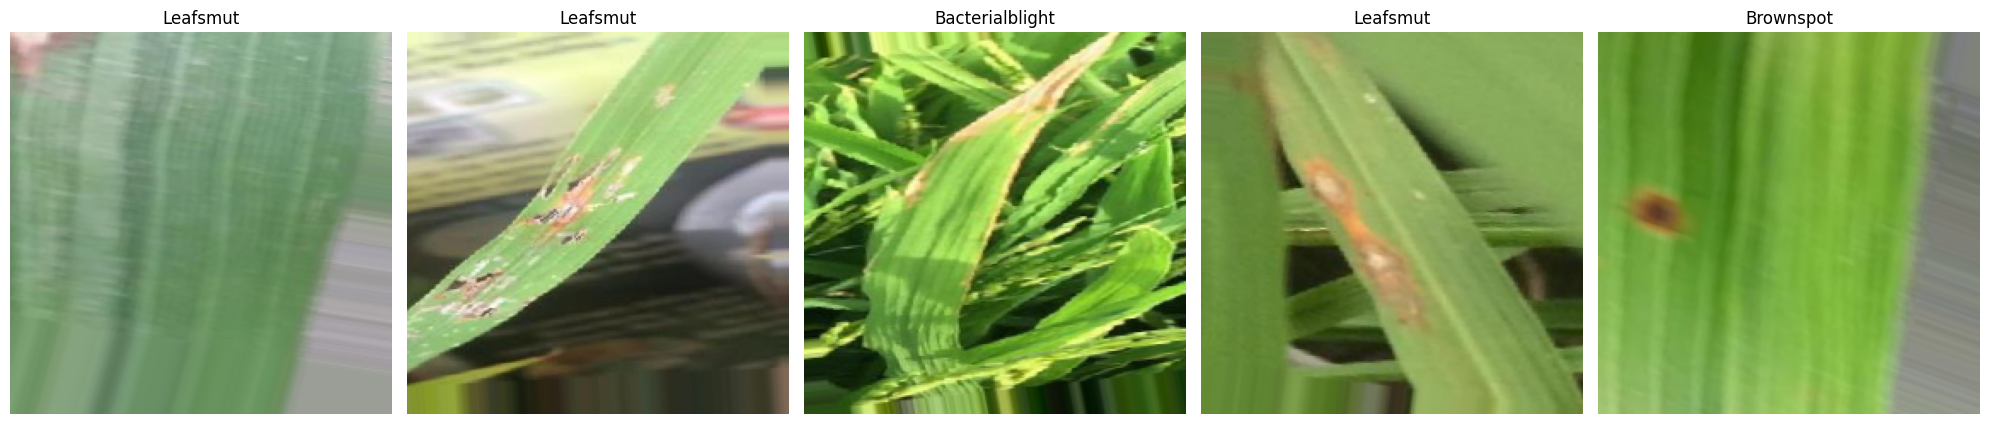

In [3]:
# Function to plot images
def plot_images(images_arr, labels_arr, class_names):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    axes = axes.flatten()
    for img, ax, label in zip(images_arr, axes, labels_arr):
        ax.imshow(img)
        # Reverse one-hot encoding to get class name
        class_idx = list(label).index(1)
        class_name = list(class_names.keys())[list(class_names.values()).index(class_idx)]
        ax.set_title(class_name)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Get a batch of images from the training set
sample_images, sample_labels = next(train_generator)

# Plot them
print("Displaying pre-processed and augmented samples:")
plot_images(sample_images[:5], sample_labels[:5], train_generator.class_indices)

**Phase 2: Model Selection & Training**

For this phase, we will use Transfer Learning with MobileNetV2.

Why MobileNetV2?

Requirement Fit: The project document asks for an "efficient detection method" and a "web app." MobileNetV2 is specifically designed to be lightweight and fast, making it perfect for web deployment where speed is critical.


Performance: It comes pre-trained on ImageNet (millions of images), so it already knows how to detect edges, textures, and shapes. We just need to "teach" it the difference between your 3 rice diseases.

**Block 4: Build the Model (Transfer Learning)**

This code downloads the pre-trained MobileNetV2, removes the top layer (which classifies 1000 generic objects), and adds a new "head" to classify your 3 specific rice diseases.

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Load the Pre-trained Base Model (MobileNetV2)
# include_top=False removes the final classification layer so we can add our own.
# weights='imagenet' uses the patterns learned from millions of real-world images.
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the Base Model
# We don't want to destroy the pre-learned features, so we make the base non-trainable initially.
base_model.trainable = False

# 3. Add Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Condense feature maps
x = Dense(128, activation='relu')(x) # Add a new dense layer for learning
x = Dropout(0.2)(x)              # Dropout helps prevent overfitting
predictions = Dense(3, activation='softmax')(x) # Output layer: 3 classes (Leaf Smut, Brown Spot, Blight)

# 4. Finalize the Model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the Model
# Learning rate is set low (0.0001) for fine-tuning.
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model architecture built successfully.")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model architecture built successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Block 5: Train the Model**

This block trains the neural network. I have included EarlyStopping, which monitors the validation loss and automatically stops training if the model stops improving. This saves time and prevents overfitting.

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define Callbacks
# Stop training if validation loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 2. Train the Model
EPOCHS = 20 # Maximum number of iterations

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

print("Training complete.")

Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 101s 686ms/step - accuracy: 0.6397 - loss: 0.8178 - val_accuracy: 0.8028 - val_loss: 0.5585
Epoch 2/20
  1/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8125 - loss: 0.5126

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.8125 - loss: 0.5126 - val_accuracy: 0.8071 - val_loss: 0.5454
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 63s 536ms/step - accuracy: 0.8105 - loss: 0.4835 - val_accuracy: 0.8707 - val_loss: 0.3905
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.8438 - loss: 0.3987 - val_accuracy: 0.8675 - val_loss: 0.3959
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 63s 534ms/step - accuracy: 0.8625 - loss: 0.3676 - val_accuracy: 0.8912 - val_loss: 0.3085
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.6875 - loss: 0.5701 - val_accuracy: 0.8901 - val_loss: 0.3252
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 61s 525ms/step - accuracy: 0.8902 - loss: 0.3076 - val_accuracy: 0.9095 - val_loss: 0.2772
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.9688 - loss: 0.1927 - val_accuracy: 0.9062 - val_loss: 0.2784
Epoch 9/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 61s 523ms/step - accuracy: 0.8977 - loss: 0.2768 - val_a

**Block 6: Evaluation & Saving**

After training, we must visualize the performance to satisfy the Model Evaluation requirement  and save the model for the web app.

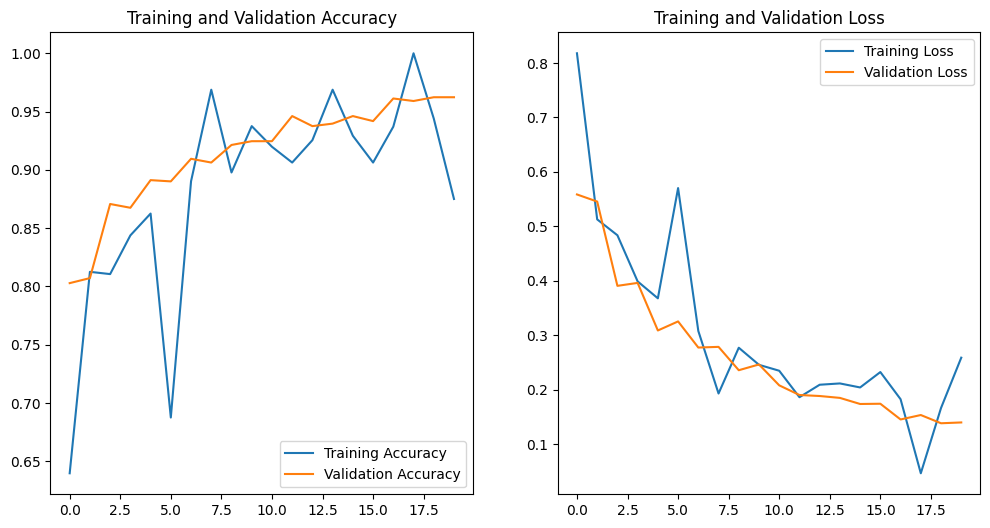

Model saved successfully at: /content/drive/My Drive/Rice_Project/rice_disease_model.h5


In [6]:
# 1. Plot Training History (Accuracy & Loss)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# 2. Save the Model
# We save it as an .h5 file, which we will download and use in the Web App later.
model_save_path = '/content/drive/My Drive/Rice_Project/rice_disease_model.h5'
model.save(model_save_path)
print(f"Model saved successfully at: {model_save_path}")

**Phase 3: Web App & Real-Time Detection**

This is the final coding phase. We will satisfy the following functional requirements here:


Web App & UI: Develop a user-friendly interface to upload images.



Real-time Detection: Implement a pipeline using OpenCV to analyze the image.



Visual Feedback: Show the original image alongside results.

We will use Streamlit. It is the standard Python tool for building data science web apps quickly and meets the "Python Only" requirement

In [21]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 94.5 MB/s eta 0:00:00


In [22]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image

# --- 1. SETTINGS & CONFIGURATION ---
# Set page title and layout
st.set_page_config(page_title="Rice Plant Disease Detector", layout="wide")

# Define the class names (Must match the order from Phase 1 training!)
# Usually alphabetical: 0: Bacterial Blight, 1: Brown Spot, 2: Leaf Smut
CLASS_NAMES = {0: 'Bacterial Leaf Blight', 1: 'Brown Spot', 2: 'Leaf Smut'}

# --- 2. LOAD MODEL FUNCTION ---
@st.cache_resource # Caches the model so it doesn't reload on every click
def get_model():
    # Make sure this path matches where you put the .h5 file
    model = load_model('/content/drive/My Drive/Rice_Project/rice_disease_model.h5')
    return model

# Load the model immediately
try:
    model = get_model()
    st.sidebar.success("Model Loaded Successfully!")
except Exception as e:
    st.sidebar.error(f"Error loading model: {e}")

# --- 3. PRE-PROCESSING PIPELINE (OpenCV) ---
def process_image(image_file):
    """
    Input: Uploaded image file
    Output: Preprocessed image ready for the model
    """
    # Convert Streamlit file to OpenCV format
    file_bytes = np.asarray(bytearray(image_file.read()), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, 1) # Read as RGB

    # Resize to 224x224 (Same as Phase 1 training)
    image_resized = cv2.resize(image, (224, 224))

    # Convert to RGB (OpenCV uses BGR by default)
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

    # Normalize pixel values (0-1) - CRITICAL: Must match training!
    image_normalized = image_rgb / 255.0

    # Expand dimensions to match batch size (1, 224, 224, 3)
    image_batch = np.expand_dims(image_normalized, axis=0)

    return image_rgb, image_batch

# --- 4. USER INTERFACE (Frontend) ---
st.title("🌾 Rice Plant Disease Detection")
st.markdown("### Upload a rice leaf image to detect: Leaf Smut, Brown Spot, or Bacterial Blight.")
st.markdown(" Painting the target, a little too much.")

# File Uploader
uploaded_file = st.file_uploader("Choose an Image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Split screen into two columns: Left (Image), Right (Results)
    col1, col2 = st.columns(2)

    with col1:
        st.info("Original Image")
        # Process the image using our OpenCV pipeline
        display_image, model_input = process_image(uploaded_file)
        # Display the uploaded image
        st.image(display_image, width='stretch')

    with col2:
        st.info("Analysis Result")

        # Make Prediction
        if model:
            predictions = model.predict(model_input)
            confidence = np.max(predictions) # Get highest probability
            predicted_class_index = np.argmax(predictions) # Get class index
            predicted_label = CLASS_NAMES.get(predicted_class_index, "Unknown")

            # Display Result
            st.success(f"**Prediction:** {predicted_label}")
            st.warning(f"**Confidence:** {confidence * 100:.2f}%")

            # Visual Bar for all probabilities
            st.write("Confidence Distribution:")
            st.bar_chart(predictions[0])

            # Simple advice based on class
            if predicted_label == 'Leaf Smut':
                st.write("ℹ️ **Note:** Caused by the fungus *Entyloma oryzae*.")
            elif predicted_label == 'Brown Spot':
                st.write("ℹ️ **Note:** Often indicates poor soil nutrition.")
            elif predicted_label == 'Bacterial Leaf Blight':
                st.write("ℹ️ **Note:** A serious disease caused by *Xanthomonas oryzae*.")

Overwriting app.py


In [23]:
!pip install pyngrok -q

### Authorize ngrok

To use ngrok, you need an authentication token.

1.  Go to [ngrok.com](https://ngrok.com/) and create a free account.
2.  After logging in, navigate to your [dashboard](https://dashboard.ngrok.com/get-started/your-authtoken) to find your authtoken.
3.  In Colab, go to the left sidebar, click on the "🔑 Secrets" tab, and add a new secret named `NGROK_AUTH_TOKEN`. Paste your authtoken there.

Once your `NGROK_AUTH_TOKEN` is set in Colab secrets, run the next cell to authorize `ngrok`.

In [24]:
from google.colab import userdata
from pyngrok import ngrok, conf

# Get ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Authenticate ngrok
if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("ngrok authtoken set successfully!")
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it.")

ngrok authtoken set successfully!


In [25]:
import subprocess
import time
import sys
from pyngrok import ngrok, conf
from google.colab import userdata

# Terminate any existing ngrok tunnels to prevent 'too many tunnels' error
ngrok.kill()

# Get ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it.")

# Start Streamlit in the background, binding to 0.0.0.0 for ngrok access
# Use sys.executable to ensure the correct Python interpreter is used
with open('streamlit_output.log', 'w') as out, open('streamlit_error.log', 'w') as err:
    streamlit_process = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", "app.py", "--server.address", "0.0.0.0"],
        stdout=out,
        stderr=err
    )

# Give Streamlit a moment to start up
print("Waiting for Streamlit to start...")
time.sleep(15) # Increased delay slightly to 15 seconds for more robust startup

# Connect ngrok to the Streamlit port 8501
tunnel = ngrok.connect(8501)
print(f"Streamlit App URL: {tunnel.public_url}")
print("Check streamlit_output.log and streamlit_error.log for Streamlit console output.")

Waiting for Streamlit to start...
Streamlit App URL: https://a94f-34-142-156-227.ngrok-free.app
Check streamlit_output.log and streamlit_error.log for Streamlit console output.


### Inspecting Streamlit Logs

Let's check the logs to see if Streamlit reported any errors or warnings during its startup. This will help us understand why ngrok might not be able to connect.

In [26]:
# Read and display Streamlit's standard output
print("\n--- Streamlit Standard Output (streamlit_output.log) ---")
try:
    with open('streamlit_output.log', 'r') as f:
        print(f.read())
except FileNotFoundError:
    print("streamlit_output.log not found.")

# Read and display Streamlit's standard error
print("\n--- Streamlit Standard Error (streamlit_error.log) ---")
try:
    with open('streamlit_error.log', 'r') as f:
        print(f.read())
except FileNotFoundError:
    print("streamlit_error.log not found.")


--- Streamlit Standard Output (streamlit_output.log) ---



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.142.156.227:8501



--- Streamlit Standard Error (streamlit_error.log) ---
2026-07-28 17:30:15.128 Uvicorn server started on 0.0.0.0:8501

